# Deep Learning: Sequential Volatility Prediction

This notebook explores advanced Deep Learning techniques for time-series forecasting. Unlike traditional Machine Learning models that look at a single snapshot in time, Recurrent Neural Networks (RNNs) like **Long Short-Term Memory (LSTM)** and **Gated Recurrent Units (GRU)** can process sequences of data, allowing them to learn temporal patterns and sequential dependencies.

**Key Steps:**
1. Deep Learning environment setup (PyTorch).
2. Data Preprocessing & Temporal Splitting.
3. Sequence Generation (creating 3D tensors of shape `[samples, time_steps, features]`).
4. Designing PyTorch Architectures (LSTM & GRU).
5. Model Training, Evaluation, and Serialization.

In [1]:
# Standard libraries
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Evaluation metrics and scaling
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# PyTorch for Deep Learning
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

### Configuration & Hyperparameters

Before loading the data, we define our global configuration, hyperparameters, and compute device. 
* `SEQ_LENGTH`: The "look-back" window. A length of 20 means the model uses the past 20 days of data to predict the target at day $t+1$.
* We also set up hardware acceleration to use a GPU (`cuda`) if available, otherwise defaulting to `cpu`.

In [2]:
# Define relative paths for inputs and outputs
DATA_PATH = '../data/quantitative_market_dataset.csv'
MODELS_DIR = '../models/'

# Ensure models directory exists
os.makedirs(MODELS_DIR, exist_ok=True)

# Hyperparameters for the sequential neural networks
SEQ_LENGTH = 20 # Look back 20 days (approx. 1 trading month)
BATCH_SIZE = 64 # Number of sequences processed together
HIDDEN_SIZE = 64 # Number of features in the hidden state
NUM_LAYERS = 2 # Number of stacked recurrent layers
EPOCHS = 30 # Number of passes through the entire training dataset
LEARNING_RATE = 0.001 # Step size for the Adam optimizer

# Set device (GPU if available, else CPU)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


### Data Loading & Preprocessing

Similar to traditional ML, we must prevent data leakage by performing a strict **temporal split** based on dates. We scale our features based *only* on the training data statistics and apply those same transformations to the test data.

In [3]:
print("Loading and preparing dataset...")
df = pd.read_csv(DATA_PATH, parse_dates=['Date'])
df = df.sort_values(by=['ticker', 'Date']).reset_index(drop=True)

# 1. Target variable: Volatility at t+1
df['target_volatility'] = df.groupby('ticker')['historical_volatility_20d'].shift(-1)
df = df.dropna().reset_index(drop=True)

# 2. Handle categorical features
df = pd.get_dummies(df, columns=['asset_class'], drop_first=True)

# Define features and target (exclude non-predictive or leaky columns)
features = [col for col in df.columns if col not in ['Date', 'ticker', 'Open', 'High', 'Low', 'Close', 'target_volatility', 'simple_return']]
target = 'target_volatility'

# Temporal Train-Test Split (80/20)
df_sorted_by_date = df.sort_values('Date').reset_index(drop=True)
split_idx = int(len(df_sorted_by_date) * 0.8)
split_date = df_sorted_by_date.loc[split_idx, 'Date']

# Split back on original dataframe to keep ticker grouping intact
train_df = df[df['Date'] < split_date].copy()
test_df = df[df['Date'] >= split_date].copy()

# Fit scaler only on training data
scaler = StandardScaler()
train_df[features] = scaler.fit_transform(train_df[features])
test_df[features] = scaler.transform(test_df[features])

# Save DL specific scaler
joblib.dump(scaler, os.path.join(MODELS_DIR, 'dl_feature_scaler.pkl'))

print(f"Train samples: {len(train_df)} | Test samples: {len(test_df)}")
print(f"Number of features: {len(features)}")

Loading and preparing dataset...
Train samples: 90691 | Test samples: 22695
Number of features: 8


### Sequence Generation

Deep Learning models for time-series require a specific 3D input format: `(Batch Size, Sequence Length, Features)`. 

We create a rolling window function to generate these sequences. It is **crucial** that we group the dataset by `ticker` before generating sequences to prevent a sequence from accidentally bridging the gap between two completely different assets (e.g., mixing the end of AAPL with the beginning of MSFT).

In [4]:
# Function to create sequences per ticker to avoid cross-asset contamination
def create_sequences(dataframe, feature_cols, target_col, seq_length):
    X, y = [], []
    # Group by ticker to ensure we don't create a sequence that overlaps two different assets
    for ticker, group in dataframe.groupby('ticker'):
        group = group.sort_values('Date')
        features_array = group[feature_cols].values
        target_array = group[target_col].values
        
        for i in range(len(group) - seq_length):
            X.append(features_array[i:(i + seq_length)])
            y.append(target_array[i + seq_length])
            
    return np.array(X), np.array(y)

print(f"Generating sequences of length {SEQ_LENGTH}...")
X_train_seq, y_train_seq = create_sequences(train_df, features, target, SEQ_LENGTH)
X_test_seq, y_test_seq = create_sequences(test_df, features, target, SEQ_LENGTH)

print(f"X_train shape: {X_train_seq.shape} | y_train shape: {y_train_seq.shape}")
print(f"X_test shape: {X_test_seq.shape} | y_test shape: {y_test_seq.shape}")

# Custom PyTorch Dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # Add dimension for output (batch, 1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create DataLoaders
train_dataset = TimeSeriesDataset(X_train_seq, y_train_seq)
test_dataset = TimeSeriesDataset(X_test_seq, y_test_seq)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Generating sequences of length 20...
X_train shape: (90291, 20, 8) | y_train shape: (90291,)
X_test shape: (22295, 20, 8) | y_test shape: (22295,)


### PyTorch Model Architectures

We define two robust recurrent architectures:
1.  **LSTM (Long Short-Term Memory):** Uses cell states and gates to maintain long-term memory and prevent the vanishing gradient problem.
2.  **GRU (Gated Recurrent Unit):** A streamlined variation of LSTM that uses fewer gates, often training faster while yielding similar performance.

In [5]:
# LSTM Architecture
class VolatilityLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super(VolatilityLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # batch_first=True means input shape is (batch, seq, feature)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        # Initialize hidden and cell states with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Decode the hidden state of the last time step
        out = self.fc(out[:, -1, :])
        return out

In [6]:
# GRU Architecture
class VolatilityGRU(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size=1):
        super(VolatilityGRU, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

### Training and Evaluation Routines

We define reusable functions for:
* **Training Loop:** Computes forward passes, calculates Mean Squared Error (MSE) loss, performs backpropagation, and updates weights.
* **Evaluation Loop:** Runs inferences without tracking gradients (`torch.no_grad()`) and calculates our key metrics (RMSE, MAE, R-Squared).

In [7]:
def train_model(model, train_loader, test_loader, epochs, lr, model_name):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_losses = []
    test_losses = []
    
    print(f"--- Training {model_name} ---")
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item()
            
        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)
        
        # Validation phase
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, labels in test_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
        val_loss = val_loss / len(test_loader)
        test_losses.append(val_loss)
        
        if (epoch + 1) % 5 == 0:
            print(f'Epoch [{epoch+1}/{epochs}] | Train Loss (MSE): {train_loss:.5f} | Val Loss (MSE): {val_loss:.5f}')
            
    return train_losses, test_losses

def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            outputs = model(inputs)
            all_preds.extend(outputs.cpu().numpy())
            all_targets.extend(labels.numpy())
            
    all_preds = np.array(all_preds).flatten()
    all_targets = np.array(all_targets).flatten()
    
    rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
    mae = mean_absolute_error(all_targets, all_preds)
    r2 = r2_score(all_targets, all_preds)
    
    return rmse, mae, r2, all_preds, all_targets

### Execution: Train and Compare

We instantiate the models, run the training cycles, and format the test results into a Pandas DataFrame for a clean comparison against our earlier Machine Learning baselines.

In [8]:
# The input dimension is equal to the number of columns in our feature set
input_dim = len(features)

# Initialize models
lstm_model = VolatilityLSTM(input_dim, HIDDEN_SIZE, NUM_LAYERS).to(device)
gru_model = VolatilityGRU(input_dim, HIDDEN_SIZE, NUM_LAYERS).to(device)

# Train LSTM
lstm_train_loss, lstm_val_loss = train_model(lstm_model, train_loader, test_loader, EPOCHS, LEARNING_RATE, "LSTM")

# Train GRU
gru_train_loss, gru_val_loss = train_model(gru_model, train_loader, test_loader, EPOCHS, LEARNING_RATE, "GRU")

# Evaluate both models on Test Set
print("\n--- Final Evaluation on Test Set ---")
lstm_rmse, lstm_mae, lstm_r2, _, _ = evaluate_model(lstm_model, test_loader)
gru_rmse, gru_mae, gru_r2, _, _ = evaluate_model(gru_model, test_loader)

# Tabulate the results
results_dl = pd.DataFrame({
    'Model': ['LSTM', 'GRU'],
    'Test_RMSE': [lstm_rmse, gru_rmse],
    'Test_MAE': [lstm_mae, gru_mae],
    'Test_R2': [lstm_r2, gru_r2]
}).set_index('Model')

display(results_dl)

--- Training LSTM ---
Epoch [5/30] | Train Loss (MSE): 0.00112 | Val Loss (MSE): 0.00106
Epoch [10/30] | Train Loss (MSE): 0.00086 | Val Loss (MSE): 0.00108
Epoch [15/30] | Train Loss (MSE): 0.00077 | Val Loss (MSE): 0.00078
Epoch [20/30] | Train Loss (MSE): 0.00069 | Val Loss (MSE): 0.00062
Epoch [25/30] | Train Loss (MSE): 0.00064 | Val Loss (MSE): 0.00073
Epoch [30/30] | Train Loss (MSE): 0.00061 | Val Loss (MSE): 0.00088
--- Training GRU ---
Epoch [5/30] | Train Loss (MSE): 0.00107 | Val Loss (MSE): 0.00098
Epoch [10/30] | Train Loss (MSE): 0.00074 | Val Loss (MSE): 0.00076
Epoch [15/30] | Train Loss (MSE): 0.00067 | Val Loss (MSE): 0.00072
Epoch [20/30] | Train Loss (MSE): 0.00057 | Val Loss (MSE): 0.00077
Epoch [25/30] | Train Loss (MSE): 0.00051 | Val Loss (MSE): 0.00080
Epoch [30/30] | Train Loss (MSE): 0.00046 | Val Loss (MSE): 0.00110

--- Final Evaluation on Test Set ---


,Test_RMSE,Test_MAE,Test_R2
Model,,,
LSTM,0.029641,0.016028,0.970465
GRU,0.033183,0.017819,0.962985


### Visualization & Serialization

Finally, we plot the learning curves to check for overfitting (e.g., if the validation loss starts spiking while training loss drops). We then save the trained weights (state dictionaries) to our models directory.

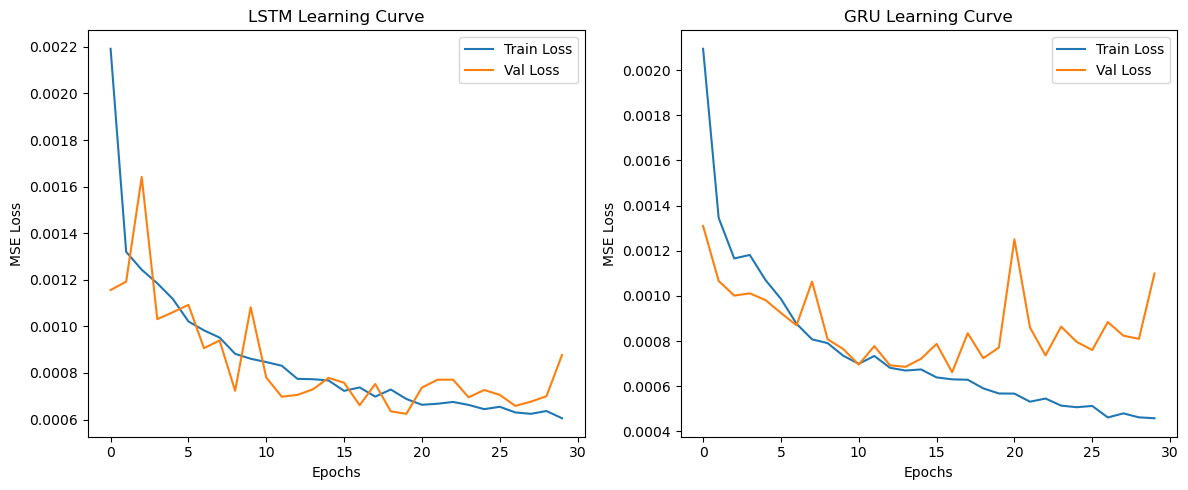

Models saved successfully to ../models/


In [9]:
# Plot training curves
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lstm_train_loss, label='Train Loss')
plt.plot(lstm_val_loss, label='Val Loss')
plt.title('LSTM Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(gru_train_loss, label='Train Loss')
plt.plot(gru_val_loss, label='Val Loss')
plt.title('GRU Learning Curve')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Save models as .pth state dictionaries
lstm_path = os.path.join(MODELS_DIR, 'lstm_volatility.pth')
gru_path = os.path.join(MODELS_DIR, 'gru_volatility.pth')

torch.save(lstm_model.state_dict(), lstm_path)
torch.save(gru_model.state_dict(), gru_path)

print(f"Models saved successfully to {MODELS_DIR}")